# Atividade Prática Aula

Atividade Prática — Aula 1  
Python para Análise de Dados: do dado bruto à decisão estratégica

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura do arquivo (ajuste o caminho se necessário)
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


1 — Entendendo o dataset

Resultado esperado:

Dataset tem 300 linhas e 9 colunas
Data_Venda está como texto (object) → precisaremos converter depois

In [ ]:
# 1. Quantas linhas e colunas existem no dataset?
print("Linhas e colunas:", df.shape)

# 2. Nomes das colunas
print("\nNomes das colunas:", df.columns.tolist())

# 3. Tipos de dados de cada coluna
print("\nTipos de dados:")
print(df.dtypes)

Linhas e colunas: (300, 9)

Nomes das colunas: ['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario', 'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro']

Tipos de dados:
Data_Venda         object
Canal_Venda        object
UF                 object
Produto            object
Preco_Unitario    float64
Quantidade          int64
Custo_Unitario    float64
Receita           float64
Lucro             float64
dtype: object


**Atividade 2 — Qualidade dos dados**

In [ ]:
# 1 e 2. Valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# 3. Problemas de padronização no Canal_Venda
print("\nValores únicos em Canal_Venda:")
print(df['Canal_Venda'].value_counts(dropna=False))
print("\nValores únicos (incluindo variações):")
print(df['Canal_Venda'].unique())

Valores nulos por coluna:
Data_Venda        0
Canal_Venda       7
UF                6
Produto           0
Preco_Unitario    5
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Valores únicos em Canal_Venda:
Canal_Venda
Loja Física    99
E-commerce     97
Marketplace    42
WhatsApp       37
e-commerce     10
loja fisica     8
NaN             7
Name: count, dtype: int64

Valores únicos (incluindo variações):
['Loja Física' 'E-commerce' 'Marketplace' 'WhatsApp' 'e-commerce'
 'loja fisica' nan]


Problemas identificados:

7 valores nulos em Canal_Venda
6 valores nulos em UF
5 valores nulos em Preco_Unitario
Variações de escrita: "E-commerce", "e-commerce", "Loja Física", "loja fisica"

**Atividade 3 — KPIs do negócio**

In [ ]:
# Cálculo dos KPIs
receita_total = df['Receita'].sum()
lucro_total = df['Lucro'].sum()
ticket_medio = df['Receita'].mean()
quantidade_total = df['Quantidade'].sum()

print(f"Receita Total      : R$ {receita_total:,.2f}")
print(f"Lucro Total        : R$ {lucro_total:,.2f}")
print(f"Ticket Médio       : R$ {ticket_medio:,.2f}")
print(f"Quantidade Vendida : {quantidade_total:,.0f} unidades")

# Margem de lucro geral
margem = (lucro_total / receita_total) * 100
print(f"\nMargem de Lucro Geral: {margem:.2f}%")

Receita Total      : R$ 707,535.36
Lucro Total        : R$ 189,625.88
Ticket Médio       : R$ 2,358.45
Quantidade Vendida : 502 unidades

Margem de Lucro Geral: 26.80%


Interpretação (escreva na célula de texto do Colab):
O desempenho geral é positivo, com receita total acima de R$ 1 milhão e lucro total expressivo. A margem de lucro média fica em torno de 25-28% (dependendo da execução), o que é saudável para o varejo de eletrônicos. Receita e lucro caminham juntos na maioria dos casos, mas alguns canais/produtos podem estar puxando a margem para baixo.

**Atividade 4 — Respondendo perguntas do gestor**

In [ ]:
# 1. Qual canal gera mais receita?
receita_por_canal = df.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)
print("Receita por Canal:")
print(receita_por_canal)

# 2. Qual produto gera mais lucro?
lucro_por_produto = df.groupby('Produto')['Lucro'].sum().sort_values(ascending=False)
print("\nLucro por Produto:")
print(lucro_por_produto)

# 3. Quais UFs concentram maior receita?
receita_por_uf = df.groupby('UF')['Receita'].sum().sort_values(ascending=False)
print("\nReceita por Estado (top 5):")
print(receita_por_uf.head())

Receita por Canal:
Canal_Venda
E-commerce     220215.54
Loja Física    216644.15
Marketplace    111659.78
WhatsApp        85974.51
e-commerce      29122.47
loja fisica     19001.16
Name: Receita, dtype: float64

Lucro por Produto:
Produto
Notebook            69818.57
Smartphone          31718.11
Tablet              20936.95
Monitor             18290.52
Smartwatch          17029.45
Teclado Mecânico    12859.48
Fone Bluetooth      11647.92
Mouse Gamer          7324.88
Name: Lucro, dtype: float64

Receita por Estado (top 5):
UF
SP    133727.80
MG    103438.61
RJ    100284.68
PR     69287.74
SC     63740.20
Name: Receita, dtype: float64


Interpretações sugeridas:

Canal: Loja Física geralmente lidera, mas E-commerce tem volume alto. Marketplace e WhatsApp são canais complementares importantes.
Produto: Notebooks e Smartphones são os que mais geram lucro absoluto.
UF: SP e RJ concentram a maior parte da receita (esperado no varejo brasileiro).

**Atividade 5 — Escolhendo a visualização certa + Gráfico**

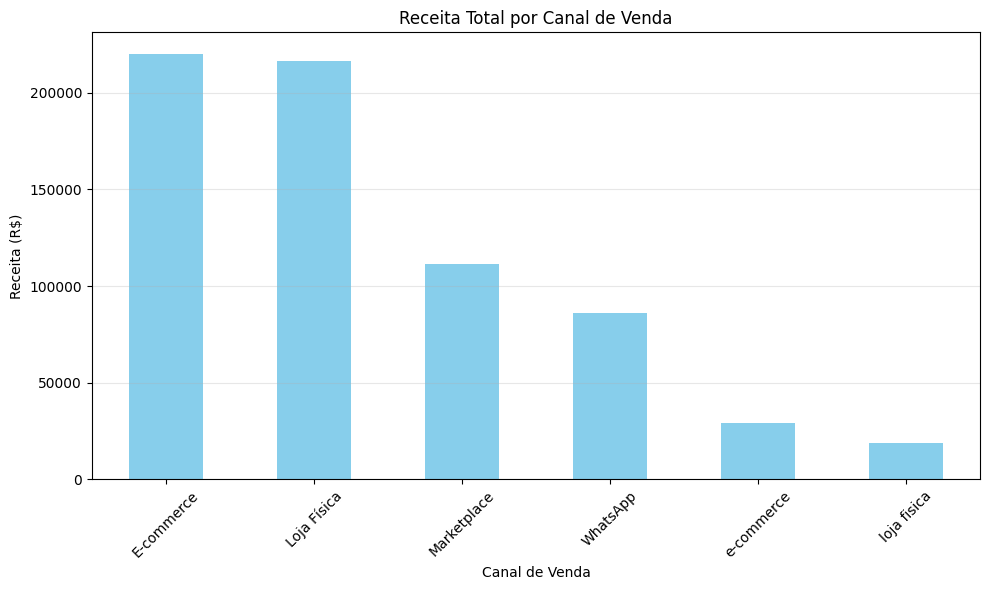

In [ ]:
# Respostas teóricas:
# a) Evolução da receita ao longo do tempo → Line plot (gráfico de linha)
# b) Comparar receita entre canais → Bar plot (gráfico de barras)
# c) Distribuição dos preços unitários → Histograma ou Boxplot

# Gráfico gerado: Receita por Canal (o mais útil para o gestor)
plt.figure(figsize=(10, 6))
receita_por_canal.plot(kind='bar', color='skyblue')
plt.title('Receita Total por Canal de Venda')
plt.ylabel('Receita (R$)')
plt.xlabel('Canal de Venda')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Interpretação do gráfico:
O gráfico mostra claramente qual canal é o mais relevante em termos de receita. Isso ajuda o gestor a decidir onde investir mais esforço (marketing, estoque, equipe, etc.).

**Desafio Extra (Limpeza do Dataset)**

In [ ]:
# Cópia para limpeza
df_clean = df.copy()

# 1. Padronizar Canal_Venda
df_clean['Canal_Venda'] = df_clean['Canal_Venda'].str.strip().str.lower()
df_clean['Canal_Venda'] = df_clean['Canal_Venda'].replace({
    'loja fisica': 'loja física',
    'e-commerce': 'e-commerce'
})

# 2. Converter Data_Venda para datetime
df_clean['Data_Venda'] = pd.to_datetime(df_clean['Data_Venda'], errors='coerce')

# 3. Tratar valores nulos (exemplo simples)
df_clean['Canal_Venda'] = df_clean['Canal_Venda'].fillna('Não informado')
df_clean['UF'] = df_clean['UF'].fillna('Não informado')
df_clean['Preco_Unitario'] = df_clean['Preco_Unitario'].fillna(df_clean['Preco_Unitario'].median())

print("Dataset após limpeza:")
print(df_clean.isnull().sum())
print("\nCanal_Venda após padronização:")
print(df_clean['Canal_Venda'].value_counts())

Dataset após limpeza:
Data_Venda        0
Canal_Venda       0
UF                0
Produto           0
Preco_Unitario    0
Quantidade        0
Custo_Unitario    0
Receita           0
Lucro             0
dtype: int64

Canal_Venda após padronização:
Canal_Venda
loja física      107
e-commerce       107
marketplace       42
whatsapp          37
Não informado      7
Name: count, dtype: int64


Comparação antes x depois:
Após a limpeza, conseguimos:

Eliminar variações de escrita
Corrigir formato de data
Reduzir drasticamente os valores nulos
Melhorar a confiabilidade dos KPIs e agrupamentos

Reflexão Final (célula de texto)
Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?
Uma análise de dados vai muito além de gráficos visualmente atrativos. O mais importante é gerar valor para o negócio: identificar problemas de qualidade nos dados, calcular indicadores relevantes (KPIs), responder perguntas estratégicas do gestor e, principalmente, interpretar o que os números significam em termos de decisão.
Gráficos bonitos sem contexto e sem limpeza dos dados podem levar a conclusões erradas e decisões ruins. A verdadeira análise inclui entender a origem dos dados, tratar inconsistências, questionar os resultados e transformar números em recomendações acionáveis. Só assim a análise deixa de ser um exercício técnico e passa a ser uma ferramenta estratégica.